#### 0.1 Imports & Configurations

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#### 0.2 Data Loading

In [32]:
# Loading the processed dataset
DATA_PATH = '../data/processed/crop_features_v1.csv'
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"  Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Columns : {df.columns.tolist()}")
print()
df.head(10)

Dataset loaded successfully.
  Shape   : 2200 rows × 11 columns
  Columns : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'moisture_index', 'P_to_K', 'ph_dev', 'label']



,N,P,K,temperature,humidity,ph,rainfall,moisture_index,P_to_K,ph_dev,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,9.719701,0.976744,0.002985,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,9.809501,1.414634,0.538096,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,9.986483,1.250000,1.340207,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,9.876557,0.875000,0.480401,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,9.973014,1.000000,1.128473,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,9.949010,0.880952,0.573454,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,10.017848,1.447368,0.799194,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,9.906445,1.325000,0.781373,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,9.865338,1.421053,0.185346,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,9.818404,1.526316,0.163746,rice


### 1.0 Logistic Regression

#### 1.1 Define Features & Label

In [33]:
# Defining the features (X) and the label (y)
features = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 
    'rainfall', 'moisture_index', 'P_to_K', 'ph_dev'
]

X = df[features]
y = df['label']

#### 1.2 Split the Dataset

In [34]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### 1.3 Feature Scaling

In [35]:
# Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 1.4 Initializing and Training the Logistic Regression Model

In [36]:
# Initialize and train the Logistic Regression model
# max_iter is increased because multi-class problems might require more iterations to converge
log_reg_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

#### 1.5 Making Predictions on the Test Dataset

In [37]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_scaled)

#### 1.6 Logistic Regression Model Evaluation

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 98.18%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      0.95      0.95        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90      0

#### 1.7 Confusion Matrix and Heatmap

Raw Logistic Regression Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  0 19  0  0  0  0  0  0

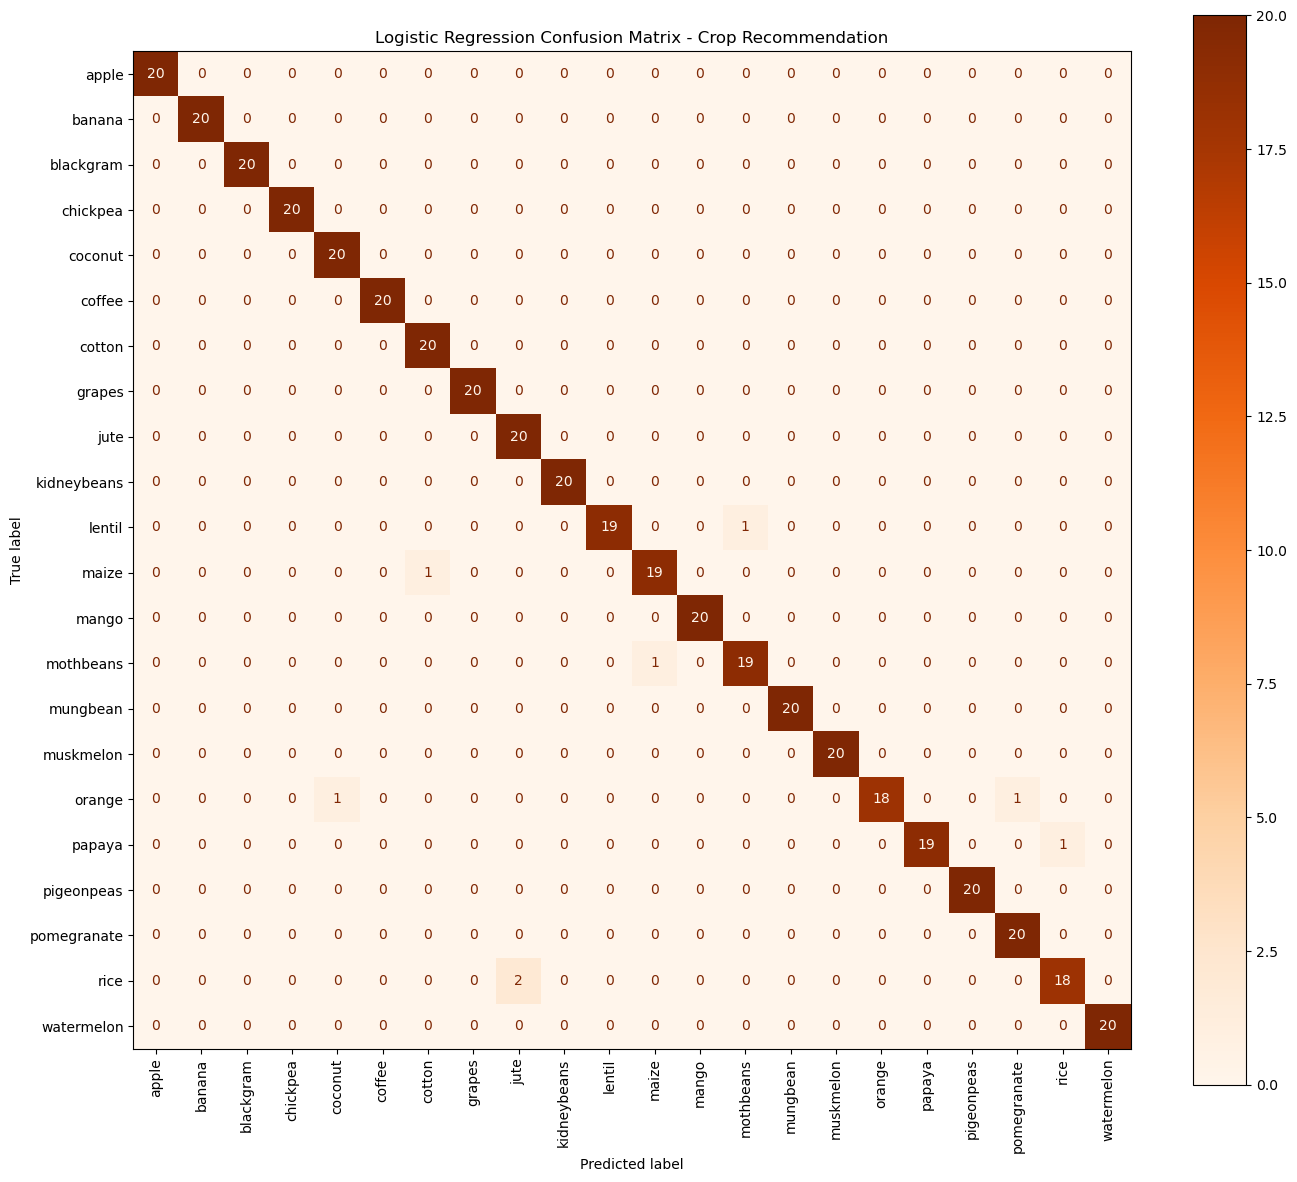

In [39]:
# Remember to use the scaled test data here as well!
y_pred_log = log_reg_model.predict(X_test_scaled)

# 2. Calculate the raw confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

print("Raw Logistic Regression Confusion Matrix:")
print(cm_log)

# 3. Create the visual heatmap
# Pulling the class labels from the trained Logistic Regression model
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_reg_model.classes_)

# Create a large figure to fit the 22 crop names comfortably
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix. Let's use 'Oranges' to visually distinguish this 
# from the Decision Tree (Blues) and SVM (Greens) plots.
disp_log.plot(cmap='Oranges', ax=ax, xticks_rotation='vertical')

plt.title('Logistic Regression Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()

#### 1.8 Discussion of Logistic Regression Results

### 2.0 SVM

#### 2.1 Data Splitting
Here we did the same split (state 42) so maybe this is redundant?

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### 2.2 Feature Scaling

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 2.3 Initialize and Train SVM

In [42]:
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

#### 2.4 Prediction and Evaluation

In [43]:
y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 98.64%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90      0

#### 2.5 Confusion Matrix and Heatmap 

Raw SVM Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0 

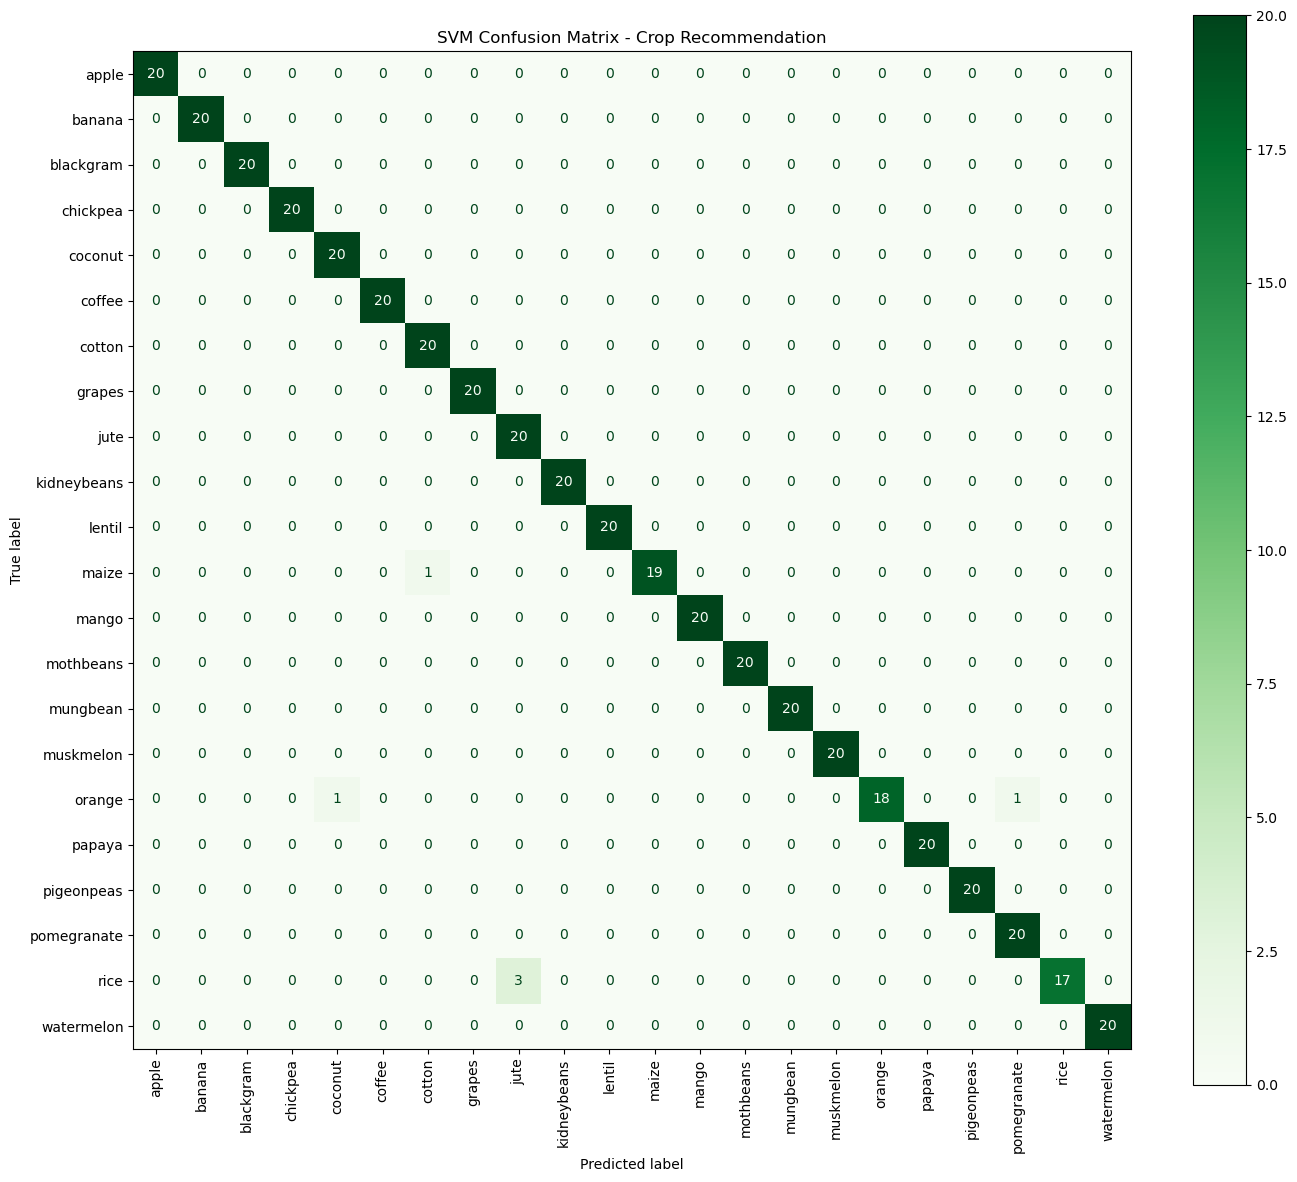

In [44]:
# 1. Generate predictions using the SVM model
# CRITICAL: Make sure you are passing the SCALED test features here!
y_pred_svm = svm_model.predict(X_test_scaled)

# 2. Calculate the raw confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Raw SVM Confusion Matrix:")
print(cm_svm)

# 3. Create the visual heatmap
# We pull the class labels directly from the trained SVM model
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)

# Create a large figure to comfortably fit all 22 crop names
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix
disp_svm.plot(cmap='Greens', ax=ax, xticks_rotation='vertical')

plt.title('SVM Confusion Matrix - Crop Recommendation')
plt.tight_layout() # Keeps the crop labels from getting cut off at the edges
plt.show()

#### 2.6 Discussion of SVM Results

### 3.0 Decision Tree

#### 3.1 Data Preparation & Splitting
We intentionally skip the StandardScaler step here

In [45]:
features = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 
    'rainfall', 'moisture_index', 'P_to_K', 'ph_dev'
]

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### 3.2 Initializing Decision Tree

In [46]:
# We set max_depth to prevent the tree from growing too complex and overfitting
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

#### 3.3 Prediction and Evaluation

In [47]:
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 96.82%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.65      1.00      0.78        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.85      0.55      0.67        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1

#### 3.4 Confusion Matrix and Heatmap

Raw Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  8  0  0 11  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  0 19  0  0  0  0  0  0  0  0]
 [ 0  0  0  

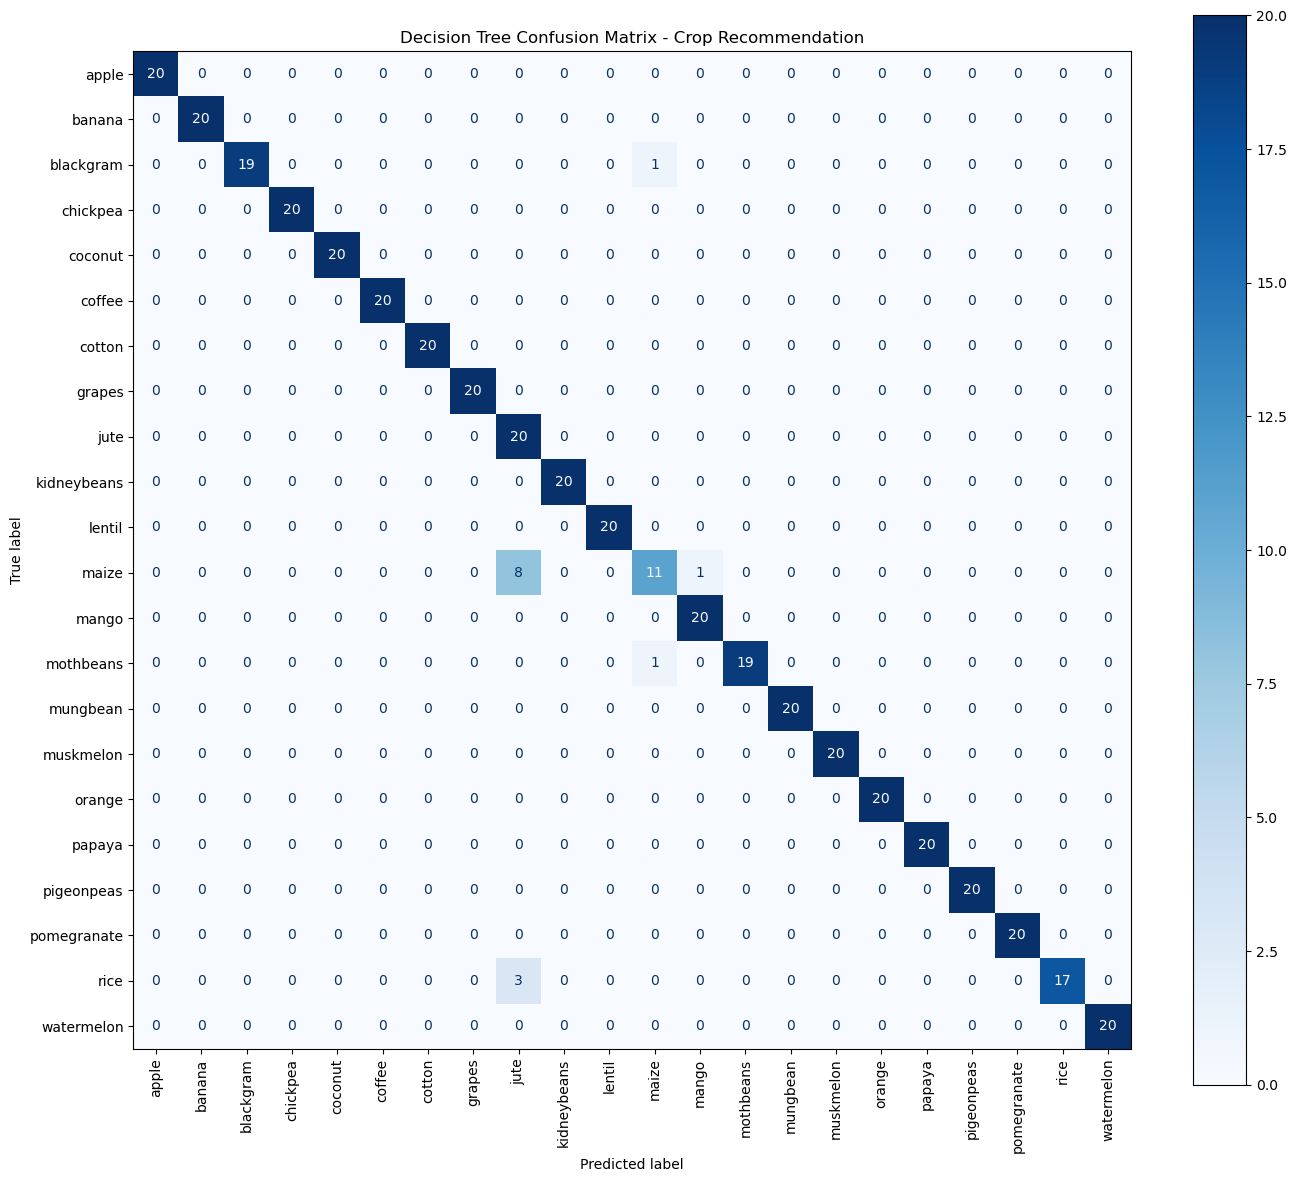

In [48]:
# 1. Calculate the raw confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Print the simple text version
print("Raw Confusion Matrix:")
print(cm)

# 3. Create a visual heatmap (Highly Recommended for multi-class)
# We use the classes_ attribute from your trained tree_model for the labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_model.classes_)

# Create a large figure so the 22 crop names don't overlap
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using a blue color map, rotating x-labels to make them readable
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title('Decision Tree Confusion Matrix - Crop Recommendation')
plt.tight_layout() # Ensures labels fit within the image
plt.show()

#### 3.5 Decision Tree Results Discussion

### 4.0 Random Forest

#### 4.1 Data Loading and Splitting

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### 4.2 Initialize and Train Random Forest

In [51]:
# n_estimators is the number of trees in the forest. 
# n_jobs=-1 tells the model to use all available CPU cores for faster training.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

#### 4.3 Predict and Evaluate

In [52]:
y_pred_rf = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 99.55%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1

#### 4.4 Confusion Matrix and Heatmap

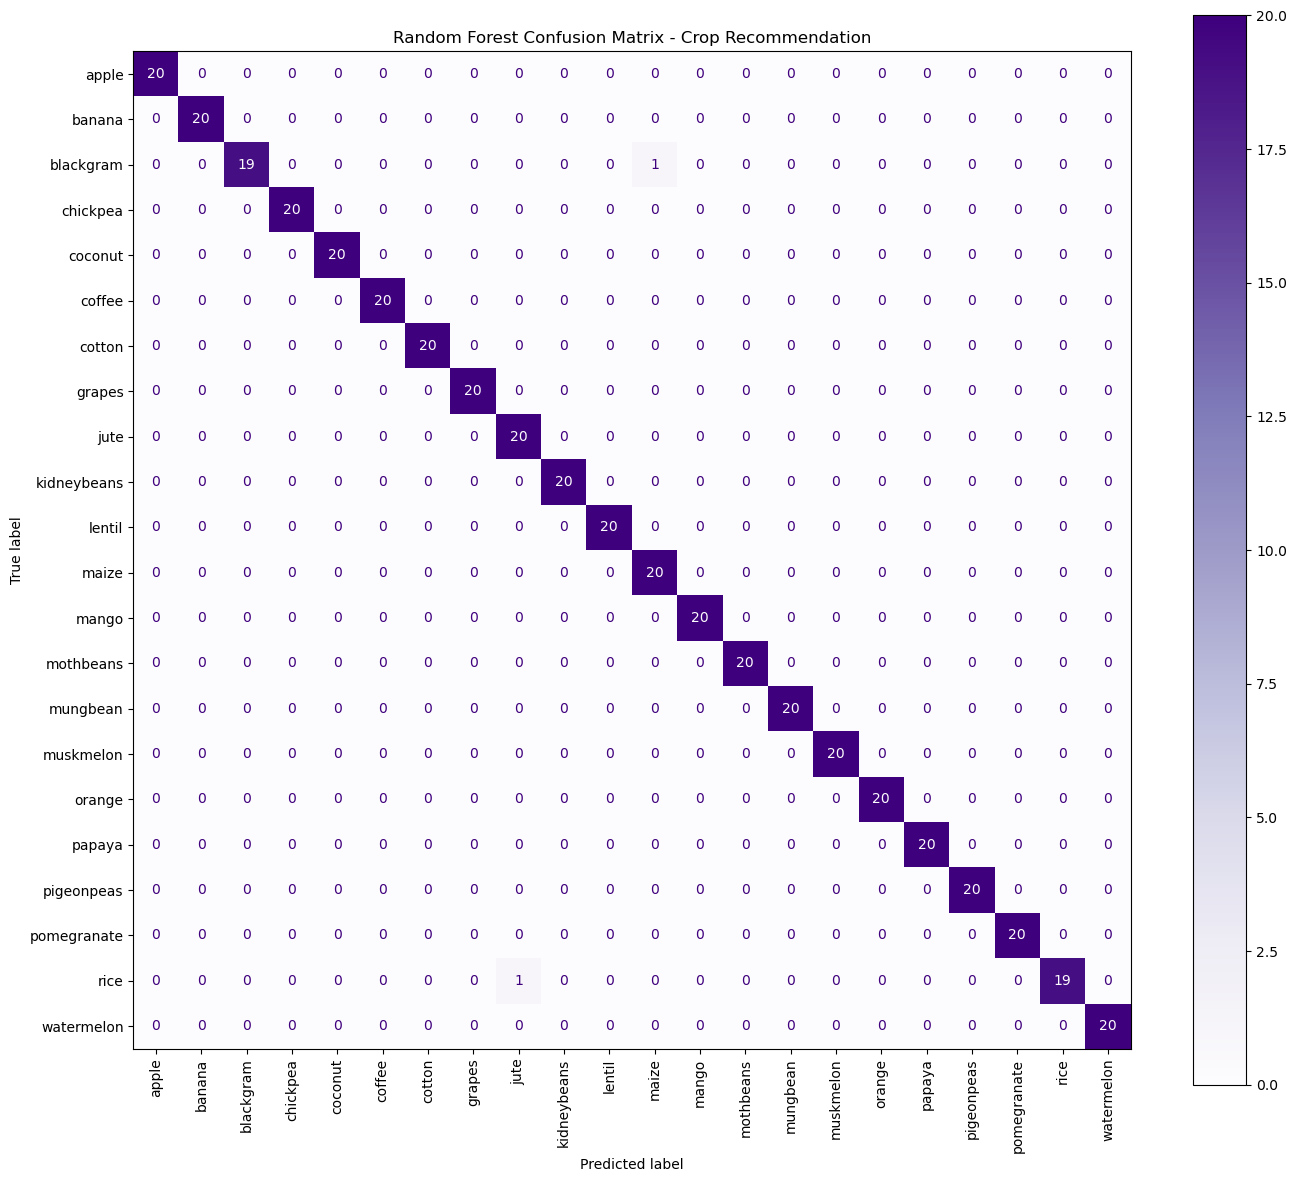

In [53]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)

fig, ax = plt.subplots(figsize=(14, 12))
# Using 'Purples' to distinguish from Logistic (Oranges), SVM (Greens), and Decision Tree (Blues)
disp_rf.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')

plt.title('Random Forest Confusion Matrix - Crop Recommendation')
plt.tight_layout()
plt.show()

#### 4.5 Random Forest Feature Importance

Feature Importances:
       Feature  Importance
      humidity    0.179999
      rainfall    0.160764
             K    0.143609
moisture_index    0.136725
             P    0.123146
             N    0.091706
        P_to_K    0.077376
   temperature    0.046041
            ph    0.027918
        ph_dev    0.012716




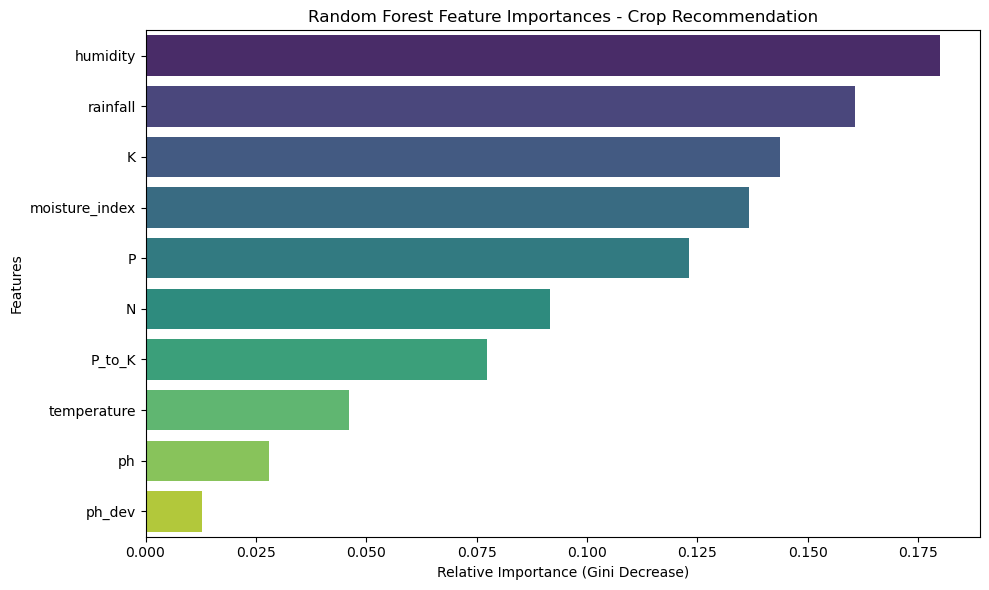

In [55]:
importances = rf_model.feature_importances_

# --- STEP 2: Create a DataFrame for easy sorting and plotting ---
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# --- STEP 3: Sort the features from most to least important ---
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the exact numerical values for reference
print("Feature Importances:")
print(feature_importance_df.to_string(index=False))
print("\n")

# --- STEP 4: Plot the Feature Importances ---
plt.figure(figsize=(10, 6))

# We use a horizontal bar chart (x='Importance', y='Feature') because it makes 
# the feature names much easier to read without overlapping.
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)

plt.title('Random Forest Feature Importances - Crop Recommendation')
plt.xlabel('Relative Importance (Gini Decrease)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

#### 4.6 Comparing to Results from Feature Engineering (?)